In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# load in CCSA data
ccsa_data = pd.read_csv('CCSA.csv')
ccsa_data.head()

,observation_date,CCSA
0,2000-01-01,2102000
1,2000-01-08,2107000
2,2000-01-15,2115000
3,2000-01-22,2061000
4,2000-01-29,2164000


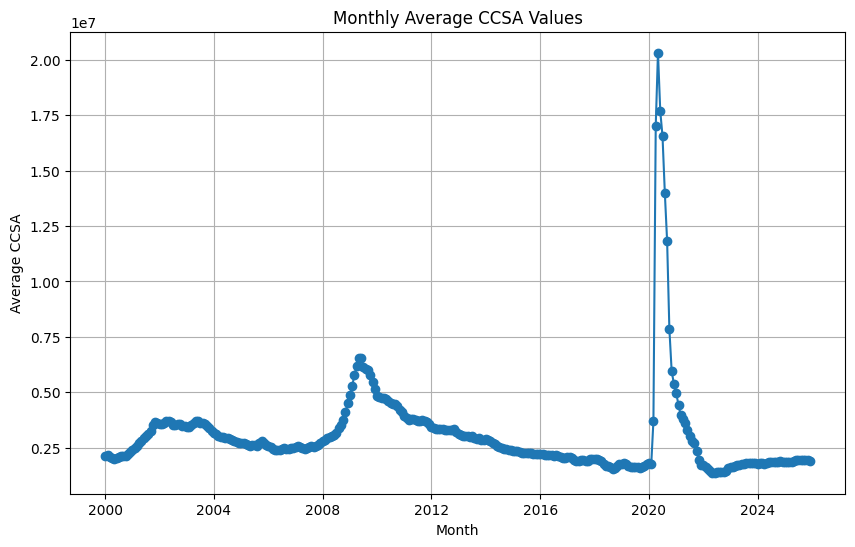

In [4]:
# plot monthly average CCSA values over time
# You will need to manipulate the data to get the monthly averages. The x-axis
# should represent the month and year, and the y-axis should represent the average
# CCSA value for that month. Make sure the plot has a title and labeled axes.

# first, create a new dataset with the month and average CCSA value for that month and year
ccsa_data['Week'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.isocalendar().week
ccsa_data['Year'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.year
ccsa_data['Month'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.month
ccsa_data['Week_of_Month'] = ((pd.to_datetime(ccsa_data['observation_date']).dt.day - 1) // 7) + 1

ccsa_monthly_avg = ccsa_data.groupby(['Year', 'Month'])['CCSA'].mean().reset_index()
ccsa_monthly_avg['Time'] = pd.to_datetime(ccsa_monthly_avg[['Year', 'Month']].assign(DAY=1))
# plot the monthly averages
plt.figure(figsize=(10, 6))
plt.plot(ccsa_monthly_avg['Time'], ccsa_monthly_avg['CCSA'], marker='o')
plt.title('Monthly Average CCSA Values')
plt.xlabel('Month')
plt.ylabel('Average CCSA')
plt.grid()
plt.show()

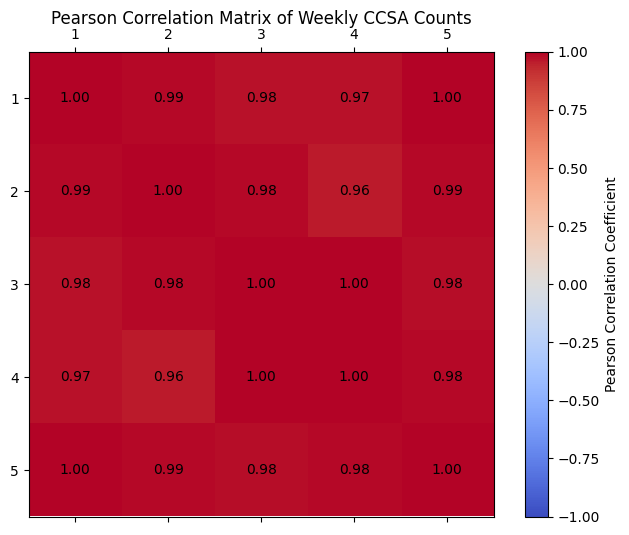

In [7]:
# b) Determine the Pearson correlations among the weekly counts. To this end, calculate the
# pairwise Pearson correlation between the counts of the rth and sth weeks of each month, where r
# and s run from 1 to 5 inclusively. Use all available non-missing counts for each pair to calculate the
# correlations. Present the correlations in a 5 × 5 matrix with proper row and column labels.

# pivot the data to have weeks as columns
ccsa_pivot = ccsa_data.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')

# calculate the Pearson correlation matrix
correlation_matrix = ccsa_pivot.corr(method='pearson')

# display correlation matrix as a heatmap with correlation values overlayed
# note: I used copilot to help generate this heatmap using the comment above as a prompt
plt.figure(figsize=(8, 6))
plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Pearson Correlation Coefficient')
plt.xticks(range(5), range(1, 6))
plt.yticks(range(5), range(1, 6))
for (i, j), val in np.ndenumerate(correlation_matrix.values):
    plt.text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
plt.title('Pearson Correlation Matrix of Weekly CCSA Counts', pad=20)
plt.show()

In [42]:
ccsa_monthly_avg.head()

,Year,Month,CCSA,Time
0,2000,1,2109800.0,2000-01-01
1,2000,2,2147500.0,2000-02-01
2,2000,3,2079000.0,2000-03-01
3,2000,4,2015400.0,2000-04-01
4,2000,5,1989500.0,2000-05-01


In [6]:
# c) Assign observations from 2000 to 2015, inclusive, to the Training partition. The Testing
# partition will contain the remaining ten years of observations. Because not all months have a fifth
# week, further split the Training partition by month into two groups. The first group includes months
# with fifth-week counts. The second group comprises months with only four weeks of counts.
# Generate principal components for the two groups in the Training partition. How many principal
# components do you choose for each group? Also, what percentage of the total variance do the
# principal components explain in each group? Please show your work to justify your choices.
ccsa_data['Week'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.isocalendar().week
ccsa_data['Year'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.year
ccsa_data['Month'] = pd.to_datetime(ccsa_data['observation_date'], format='%Y-%m-%d').dt.month
ccsa_data['Week_of_Month'] = ((ccsa_data['Week'] - 1) % 5) + 1
ccsa_train = ccsa_data[(ccsa_data['Year'] >= 2000) & (ccsa_data['Year'] <= 2015)]
ccsa_test = ccsa_data[(ccsa_data['Year'] > 2015)]

ccsa_train_pivot = ccsa_train.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
train_w_fifth = ccsa_train_pivot.dropna()
train_wo_fifth = ccsa_train_pivot[ccsa_train_pivot[5].isna()].drop(columns=[5]).dropna()

# ccsa_train_pivot.head()

train_wo_fifth.head()
# ccsa_test_pivot = ccsa_test.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
# test_w_fifth = ccsa_test_pivot.dropna(subset=[5])
# test_wo_fifth = ccsa_test_pivot[ccsa_test_pivot[5].isna()]

Week_of_Month          1          2          3          4
Year Month                                               
2000 1         2107000.0  2108500.0  2061000.0  2164000.0
     8         2096000.0  2109000.0  2145000.0  2119000.0
2001 1         2357000.0  2367000.0  2419000.0  2440000.0
     8         3079000.0  3125000.0  3113000.0  3163000.0
2002 1         3587000.0  3500000.0  3557000.0  3558000.0

Explained variance ratios for months with fifth week:
[9.97511968e-01 1.07964099e-03 7.29877266e-04 3.76350887e-04
 3.02162617e-04]


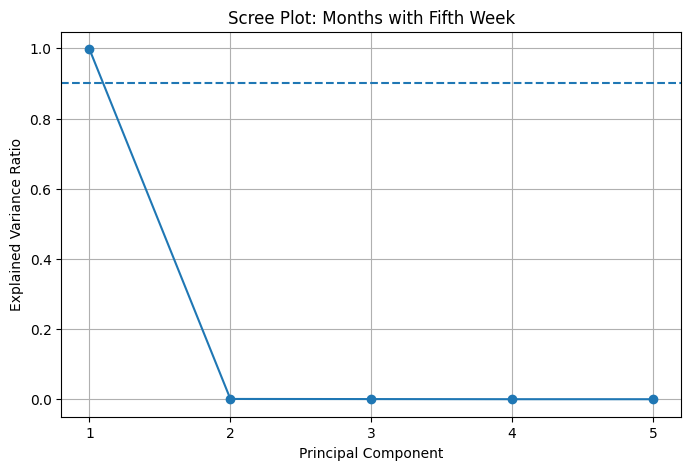

In [8]:
pca_5 = PCA()
pca_5.fit(train_w_fifth)

print("Explained variance ratios for months with fifth week:")
print(pca_5.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_5.explained_variance_ratio_) + 1),
    pca_5.explained_variance_ratio_,
    marker='o'
)
plt.axhline(0.9, linestyle='--', label='90% Variance')
plt.title('Scree Plot: Months with Fifth Week')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 6))
plt.grid()
plt.show()

Explained variance ratios for months without fifth week:
[9.98416754e-01 1.07738764e-03 2.65291238e-04 2.40567482e-04]


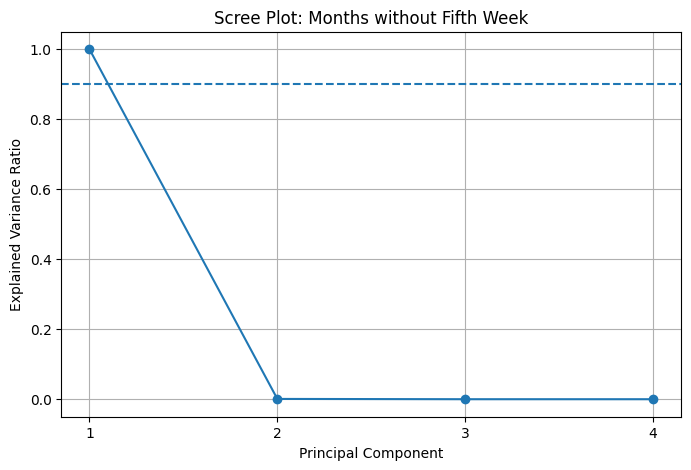

In [9]:
pca_4 = PCA()
pca_4.fit(train_wo_fifth)

print("Explained variance ratios for months without fifth week:")
print(pca_4.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_4.explained_variance_ratio_) + 1),
    pca_4.explained_variance_ratio_,
    marker='o'
)
plt.axhline(0.9, linestyle='--', label='90% Variance')
plt.title('Scree Plot: Months without Fifth Week')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 5))
plt.grid()
plt.show()

In [10]:
pca_5.n_components = 1
pca_5.fit(train_w_fifth)

pca_4.n_components = 1
pca_4.fit(train_wo_fifth)

,n_components,1
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [11]:
# create groups in testing partition
ccsa_test_pivot = ccsa_test.pivot_table(index=['Year', 'Month'], columns='Week_of_Month', values='CCSA')
test_w_fifth = ccsa_test_pivot.dropna()
test_wo_fifth = ccsa_test_pivot[ccsa_test_pivot[5].isna()].drop(columns=[5]).dropna()

# transform testing data using trained pca models
test_w_fifth_pca = pca_5.transform(test_w_fifth)
test_wo_fifth_pca = pca_4.transform(test_wo_fifth)

In [13]:
test_w_fifth_pca_df = pd.DataFrame(test_w_fifth_pca, index=test_w_fifth.index, columns=[f'PC1'])
test_wo_fifth_pca_df = pd.DataFrame(test_wo_fifth_pca, index=test_wo_fifth.index, columns=[f'PC1'])
test_pca_concat = pd.concat([test_w_fifth_pca_df, test_wo_fifth_pca_df]).sort_index()

test_pca_concat.head()

PC1
Year Month              
2016 1     -1.988562e+06
     4     -2.336780e+06
     7     -2.368980e+06
     8     -2.113244e+06
     10    -2.507596e+06

In [15]:
# print the variances of the principal components applied to the Testing partition
print("Variances of the principal components in the Testing partition:")
print(test_pca_concat.var())

Variances of the principal components in the Testing partition:
PC1    4.959071e+13
dtype: float64


### Question 2

In [10]:
# load in the data
retail_data = pd.read_csv('Retail_Theft_20260109 (1).csv')
retail_data.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14071609,JK100791,12/31/2025 09:15:00 PM,009XX W IRVING PARK RD,860,THEFT,RETAIL THEFT,DRUG STORE,False,False,...,46.0,6.0,6,1169204.0,1926746.0,2025,2026 Jan 08 03:46:48 PM,41.954507,-87.653373,POINT (-87.653372774 41.954507152)
1,14071604,JK100442,12/31/2025 07:21:00 PM,032XX N CLARK ST,860,THEFT,RETAIL THEFT,DEPARTMENT STORE,False,False,...,44.0,6.0,6,1169868.0,1921628.0,2025,2026 Jan 08 03:46:48 PM,41.940449,-87.651082,POINT (-87.651081589 41.94044868)
2,14071238,JK100579,12/31/2025 07:07:00 PM,012XX W 79TH ST,860,THEFT,RETAIL THEFT,DRUG STORE,False,False,...,17.0,71.0,6,1169539.0,1852401.0,2025,2026 Jan 08 03:46:48 PM,41.750491,-87.654302,POINT (-87.654302474 41.750490827)
3,14071589,JK100443,12/31/2025 05:43:00 PM,027XX N CLYBOURN AVE,860,THEFT,RETAIL THEFT,SMALL RETAIL STORE,False,False,...,32.0,7.0,6,1162872.0,1918208.0,2025,2026 Jan 08 03:46:48 PM,41.931214,-87.676890,POINT (-87.676890454 41.93121391)
4,14070595,JJ540418,12/31/2025 04:46:00 PM,032XX N CLARK ST,860,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,...,44.0,6.0,6,1169868.0,1921628.0,2025,2026 Jan 08 03:46:48 PM,41.940449,-87.651082,POINT (-87.651081589 41.94044868)


In [11]:
# data types
retail_data.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                      int64
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                    float64
Community Area          float64
FBI Code                  int64
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [12]:
# print missing values
print(retail_data.isnull().sum())

ID                        0
Case Number               0
Date                      0
Block                     0
IUCR                      0
Primary Type              0
Description               0
Location Description      3
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                     12
Community Area           48
FBI Code                  0
X Coordinate            948
Y Coordinate            948
Year                      0
Updated On                0
Latitude                948
Longitude               948
Location                948
dtype: int64


In [22]:
from matplotlib.ticker import AutoLocator, MultipleLocator
from mlxtend.frequent_patterns import (apriori, association_rules)
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
# load in the data
retail_data = pd.read_csv('Retail_Theft_20260109 (1).csv')

# Create the dataset as described in the assignment

# Ensure Date is datetime
retail_data['Date'] = pd.to_datetime(retail_data['Date'])

# Retail theft filter
df_rt = retail_data[
    (retail_data['Year'] == 2025)
].copy()

# Allowed locations
allowed_locations = [
    'DEPARTMENT STORE',
    'SMALL RETAIL STORE',
    'GROCERY FOOD STORE',
    'DRUG STORE',
    'CONVENIENCE STORE',
    'GAS STATION',
    'TAVERN/LIQUOR STORE',
    'COMMERCIAL / BUSINESS OFFICE',
    'RESTAURANT',
    'APPLIANCE STORE',
    'WAREHOUSE',
    'TAVERN / LIQUOR STORE'
]

df_rt = df_rt[
    df_rt['Location Description'].isin(allowed_locations)
]

df_rt['Month'] = df_rt['Date'].dt.month
df_rt['Hour'] = df_rt['Date'].dt.hour

def police_watch(hour):
    if 5 <= hour <= 11:
        return 'First'
    elif hour == 12:
        return 'First->Second'
    elif 13 <= hour <= 19:
        return 'Second'
    elif hour == 20:
        return 'Second->Third'
    elif hour in [21, 22, 23, 0, 1, 2, 3]:
        return 'Third'
    elif hour == 4:
        return 'Third->First'
    else:
        return 'Unknown'

df_rt['Police Watch'] = df_rt['Hour'].apply(police_watch)

df_final = df_rt[['Arrest', 'Location Description', 'Month', 'Police Watch', 'Beat']].copy()

df_final = df_final.dropna()

/var/folders/hf/8cmwp2xj1kl_vshvblvw8shw0000gn/T/ipykernel_13204/1509178313.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  retail_data['Date'] = pd.to_datetime(retail_data['Date'])


In [35]:
# We first train our association rules using the 862 observations from Beats #111, #112, and #113
# combined. Subsequently, we will test our association rules using the 410 observations from Beat #1834.
df_train = df_final[df_final['Beat'].isin([111, 112, 113])].copy()
df_test = df_final[df_final['Beat'] == 1834].copy()
df_train = df_train.drop(columns = ['Beat'])
df_test = df_test.drop(columns = ['Beat'])

In [26]:
print(len(df_train), len(df_test))

862 410


In [43]:
# a) (10 points) Discover association rules with a minimum Support of five incidents and a minimum Lift
# of one. We only want association rules whose Consequents contain a particular 1-item set. That 1-
# item set is either {Arrest is True} or {Arrest is False}. After removing redundant rules, how many
# association rules remain with {Arrest is True} in the consequent? How many association rules remain
# with {Arrest is False} in the consequent?

# preprocess data for association rule mining
df_train['Arrest'] = df_train['Arrest'].astype(str)
transactions = df_train.apply(lambda row: [f"{col}={row[col]}" for col in df_train.columns], axis=1).tolist()  

# encode transactions into indicator format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
retail_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# find frequent itemsets
prop_support = 5/retail_encoded.shape[0]
frequent_itemsets = apriori(retail_encoded, min_support=prop_support, use_colnames=True)

# generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# filter rules for Arrest=True and Arrest=False in the consequent
rules_arrest_true = rules[rules['consequents'].apply(lambda x: 'Arrest=True' in x)]
rules_arrest_false = rules[rules['consequents'].apply(lambda x: 'Arrest=False' in x)]

In [44]:
# def remove_redundant_rules(rules):
#     # sort rules by length of antecedents and consequents
#     rules = rules.copy()
#     rules['rule_length'] = rules['antecedents'].apply(lambda x: len(x)) + rules['consequents'].apply(lambda x: len(x))
#     rules = rules.sort_values(by='rule_length')

#     non_redundant_rules = []
#     for i, rule in rules.iterrows():
#         is_redundant = False
#         for j in non_redundant_rules:
#             if j['antecedents'].issubset(rule['antecedents']) and j['consequents'].issubset(rule['consequents']):
#                 is_redundant = True
#                 break
#         if not is_redundant:
#             non_redundant_rules.append(rule)
    
#     return pd.DataFrame(non_redundant_rules).drop(columns=['rule_length'])

# Simplify rules by removing redundant rules with lower confidence
# Class code
def simplify_rule (rule_df):
    rule_sorted = rule_df.sort_values(by = 'confidence', ascending = False)
    all_index = rule_sorted.index
    n_rule = rule_sorted.shape[0]
    index_to_drop = []
    for i in range(n_rule):
        s1 = rule_sorted.iloc[i]['antecedents']
        for j in range(i+1,n_rule):
            s2 = rule_sorted.iloc[j]['antecedents']
            if (s1.issuperset(s2)):
                index_to_drop.append(all_index[j])
    simplified_rule_df = rule_sorted.drop(index_to_drop)
    return simplified_rule_df

# remove redundant rules
# rules_arrest_true_nr = remove_redundant_rules(rules_arrest_true)
# rules_arrest_false_nr = remove_redundant_rules(rules_arrest_false)

rules_arrest_true_nr = simplify_rule(rules_arrest_true)
rules_arrest_false_nr = simplify_rule(rules_arrest_false)

# print the number of non-redundant rules
print(f"Number of non-redundant rules with Arrest=True in the consequent: {len(rules_arrest_true_nr)}")
print(f"Number of non-redundant rules with Arrest=False in the consequent: {len(rules_arrest_false_nr)}")

Number of non-redundant rules with Arrest=True in the consequent: 30
Number of non-redundant rules with Arrest=False in the consequent: 47


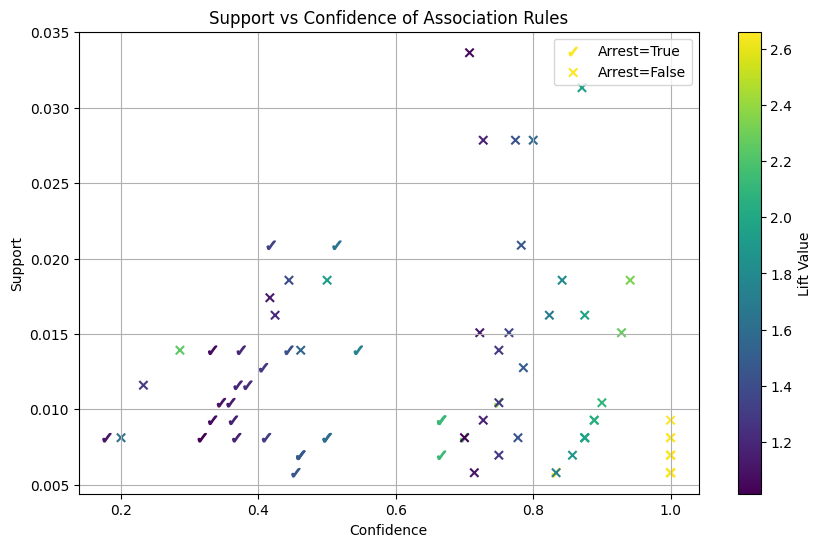

In [33]:
# b) (10 points) Plot the Support values against the Confidence values of the association rules of interest
# in Part (b). Use the checkmark ('$\u2713$') if an arrest is made and the 'x' marker if no arrest is
# made. Also, color-code the markers according to the lift values in the rules.

plt.figure(figsize=(10, 6))
scatter_true = plt.scatter(
    rules_arrest_true_nr['confidence'],
    rules_arrest_true_nr['support'],
    c=rules_arrest_true_nr['lift'],
    cmap='viridis',
    marker='$\u2713$',
    label='Arrest=True'
)
scatter_false = plt.scatter(
    rules_arrest_false_nr['confidence'],
    rules_arrest_false_nr['support'],
    c=rules_arrest_false_nr['lift'],
    cmap='viridis',
    marker='x',
    label='Arrest=False'
)
plt.colorbar(scatter_true, label='Lift Value')
plt.title('Support vs Confidence of Association Rules')
plt.ylabel('Support')
plt.xlabel('Confidence')
plt.legend()
plt.grid()
plt.show()

In [37]:
# c)(10 points) Apply the association rules to the testing partition and produce the Confusion Matrix. 
# What is the accuracy? Also, what percentage of observations do the association rules fail to deliver 
# any definitive predictions for?

# 1. Prepare Test Transactions WITHOUT the 'Arrest' feature to prevent leakage
# We drop 'Arrest' from the features so the rules must predict it
test_features = df_test.drop(columns=['Arrest'])
test_transactions = test_features.apply(
    lambda row: [f"{col}={row[col]}" for col in test_features.columns],
    axis=1
).tolist()

predictions = []
actual_labels = df_test['Arrest'].astype(int).tolist()

# 2. Combine all non-redundant rules for prediction
all_rules = pd.concat([rules_arrest_true_nr, rules_arrest_false_nr])

# 3. Prediction Loop
for transaction in test_transactions:
    matched_rules = []
    
    # Check if rule antecedents are a subset of the transaction features
    for _, rule in all_rules.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            matched_rules.append(rule)

    if matched_rules:
        # Resolve multiple matches by choosing the rule with the highest confidence
        best_rule = max(matched_rules, key=lambda x: x['confidence'])
        if 'Arrest=True' in best_rule['consequents']:
            predictions.append(1)
        else:
            predictions.append(0)
    else:
        # Track cases where no rules apply
        predictions.append(None)

# 4. Filter for valid predictions to build the matrix
valid_results = [(p, a) for p, a in zip(predictions, actual_labels) if p is not None]
y_pred, y_true = zip(*valid_results) if valid_results else ([], [])

# 5. Generate the Confusion Matrix
from sklearn.metrics import confusion_matrix as sk_cm

cm_array = sk_cm(y_true, y_pred, labels=[1, 0])
cm_df = pd.DataFrame(
    cm_array, 
    index=['Actual Arrest', 'Actual No Arrest'], 
    columns=['Predicted Arrest', 'Predicted No Arrest']
)

print("Corrected Confusion Matrix:")
print(cm_df)

# 6. Calculate Metrics
accuracy = sum(1 for p, a in valid_results if p == a) / len(valid_results) if valid_results else 0
no_prediction_rate = predictions.count(None) / len(predictions)

print(f"\nAccuracy (excluding 'None'): {accuracy:.2%}")
print(f"No Prediction Rate: {no_prediction_rate:.2%}")

Corrected Confusion Matrix:
                  Predicted Arrest  Predicted No Arrest
Actual Arrest                   27                   82
Actual No Arrest                67                  203

Accuracy (excluding 'None'): 60.69%
No Prediction Rate: 7.56%


In [38]:
rules_arrest_true_nr = rules_arrest_true_nr.reset_index(drop=True)
rules_arrest_false_nr = rules_arrest_false_nr.reset_index(drop=True)

rules_arrest_true_nr['rule_id'] = ['T' + str(i+1) for i in range(len(rules_arrest_true_nr))]
rules_arrest_false_nr['rule_id'] = ['F' + str(i+1) for i in range(len(rules_arrest_false_nr))]

from collections import defaultdict

invocation_counts = defaultdict(int)

for transaction in test_transactions:
    for _, rule in rules_arrest_true_nr.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            invocation_counts[rule['rule_id']] += 1

    for _, rule in rules_arrest_false_nr.iterrows():
        if rule['antecedents'].issubset(set(transaction)):
            invocation_counts[rule['rule_id']] += 1

rules_arrest_true_nr['invocations'] = rules_arrest_true_nr['rule_id'].map(invocation_counts).fillna(0).astype(int)
rules_arrest_false_nr['invocations'] = rules_arrest_false_nr['rule_id'].map(invocation_counts).fillna(0).astype(int)


In [39]:
top3_arrest = rules_arrest_true_nr.sort_values(
    by='invocations',
    ascending=False
).head(3)


In [40]:
top3_no_arrest = rules_arrest_false_nr.sort_values(
    by='invocations',
    ascending=False
).head(3)


In [41]:
cols_to_show = [
    'rule_id',
    'invocations',
    'antecedents',
    'confidence',
    'lift'
]

print("Top 3 Arrest=True Rules")
display(top3_arrest[cols_to_show])

print("Top 3 Arrest=False Rules")
display(top3_no_arrest[cols_to_show])


Top 3 Arrest=True Rules


,rule_id,invocations,antecedents,confidence,lift
27,T28,20,"(Location Description=DEPARTMENT STORE, Month=11)",0.333333,1.064198
13,T14,18,"(Police Watch=First, Month=11)",0.461538,1.473504
29,T30,16,"(Police Watch=Second, Month=3)",0.179487,1.113079


Top 3 Arrest=False Rules


,rule_id,invocations,antecedents,confidence,lift
10,F11,57,"(Police Watch=First, Location Description=DRUG...",0.941176,1.370429
43,F44,20,"(Location Description=DEPARTMENT STORE, Month=11)",0.416667,1.050195
44,F45,19,"(Police Watch=Second, Month=11)",0.285714,1.345824


In [42]:
# --- Part 2e: Grounded Recommendation for Susan ---

# 1. Filter the non-redundant 'Arrest=False' rules for Susan's specific situation
# We look for rules where the Location is 'SMALL RETAIL STORE'
susan_specific_rules = rules_arrest_false_nr[
    rules_arrest_false_nr['antecedents'].apply(lambda x: 'Location Description=SMALL RETAIL STORE' in x)
].copy()

# 2. Sort these rules by confidence
# High confidence in 'Arrest=False' means the police are statistically less likely 
# to make an arrest during that time/condition.
susan_specific_rules = susan_specific_rules.sort_values(by='confidence', ascending=False)

print("Rules for SMALL RETAIL STORE leading to No Arrest:")
print(susan_specific_rules[['antecedents', 'consequents', 'confidence', 'lift']])

# 3. Logic to extract the specific watch from the top rule
if not susan_specific_rules.empty:
    top_rule = susan_specific_rules.iloc[0]
    # Extract the shift name (e.g., 'Second') from the frozen set antecedent
    recommended_watch = [item.split('=')[1] for item in top_rule['antecedents'] if 'Police Watch' in item]
    
    if recommended_watch:
        print(f"\nFinal Recommendation: Susan should hire a guard during the {recommended_watch[0]} watch.")
        print(f"Reasoning: The rule {top_rule['antecedents']} -> Arrest=False has the highest confidence "
              f"({top_rule['confidence']:.2%}), suggesting police effectiveness or availability is lowest then.")
    else:
        print("\nRecommendation: Hire a guard during the shifts identified in the top rules for this location.")
else:
    print("No specific rules found for SMALL RETAIL STORE and Arrest=False. "
          "Consider lowering the minimum support threshold.")

Rules for SMALL RETAIL STORE leading to No Arrest:
                                          antecedents  \
3   (Police Watch=First, Month=1, Location Descrip...   
4   (Police Watch=First, Location Description=SMAL...   
8   (Police Watch=Second, Location Description=SMA...   
11  (Police Watch=Second, Month=4, Location Descri...   
20  (Police Watch=First, Location Description=SMAL...   
21  (Police Watch=Second, Location Description=SMA...   
23  (Police Watch=Second, Month=12, Location Descr...   
25  (Police Watch=Second, Location Description=SMA...   
40  (Location Description=SMALL RETAIL STORE, Mont...   
46  (Month=6, Location Description=SMALL RETAIL ST...   

                            consequents  confidence      lift  
3                        (Arrest=False)    1.000000  1.456081  
4                        (Arrest=False)    1.000000  1.456081  
8                        (Arrest=False)    1.000000  1.456081  
11                       (Arrest=False)    0.928571  1.352075  
2